# Assignment 3 — Logistic Regression on Wine Quality

## Topic Explanation

### What is Classification?
**Classification** is a supervised learning task where the goal is to predict a **discrete category** for each input. Unlike regression which outputs a continuous number, classification outputs a label.

Examples:
- Is this email spam or not? (binary)
- Is this tumor malignant or benign? (binary)
- Is this wine good or bad? *(this assignment — binary)*

### What is Logistic Regression?
**Logistic Regression** is a classification algorithm that, despite its name, **predicts probabilities**. It works in three steps:

1. **Linear part** — compute a weighted sum of features:
   > z = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ
   This `z` can be any number — positive, negative, large, small.

2. **Sigmoid squashing** — pass `z` through the sigmoid function to convert it into a probability between 0 and 1:
   > P(class = 1) = σ(z) = 1 / (1 + e⁻ᶻ)

3. **Threshold** — apply a cutoff (default 0.5) to convert the probability into a final class label:
   > if probability ≥ 0.5 → predict class 1
   > if probability < 0.5 → predict class 0

### Why "Regression" if it's Classification?
Historical naming. The math originally came from regression analysis. **Logistic regression is a classification algorithm.**

### The Sigmoid Function

**Formula:** σ(z) = 1 / (1 + e⁻ᶻ)

**Behavior:**
- When z is very negative → σ(z) ≈ 0
- When z = 0 → σ(z) = 0.5 (the decision boundary)
- When z is very positive → σ(z) ≈ 1

It produces an S-shaped curve that smoothly maps any real number into the (0, 1) range.

### Why Not Use Linear Regression for Classification?

1. **Output isn't bounded** — linear regression can output anything from −∞ to +∞, but probabilities must be in [0, 1].
2. **Can't interpret as probability** — even within [0, 1], a linear-regression output is just a number on a line.
3. **Sensitive to outliers** — a single extreme value can drastically tilt the regression line.

### Cost Function — Log Loss
Logistic regression uses **log loss** (also called **binary cross-entropy**):
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

This heavily penalizes confident wrong predictions.

### The Confusion Matrix

For binary classification, every prediction falls into one of four cells:

|                    | Predicted: Bad (0) | Predicted: Good (1) |
|--------------------|--------------------|---------------------|
| **Actual: Bad (0)**  | True Negative (TN) ✅  | False Positive (FP) ❌ |
| **Actual: Good (1)** | False Negative (FN) ❌ | True Positive (TP) ✅  |

### Performance Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Fraction of correct predictions |
| **Error Rate** | (FP + FN) / Total = 1 − Accuracy | Fraction of wrong predictions |
| **Precision** | TP / (TP + FP) | When model says positive, how often correct |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many caught |

We classify wines as **good (quality ≥ 7)** or **bad (quality < 7)** based on 11 chemical features.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — machine learning utilities
from sklearn.model_selection import train_test_split          # split data
from sklearn.preprocessing import StandardScaler              # feature scaling
from sklearn.linear_model import LogisticRegression           # the classifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# Load the wine quality dataset
df = pd.read_csv('winequality_red.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,10.45,0.242,0.20,2.56,0.124,67.0,22.0,0.9955,3.39,0.48,8.6,3
1,6.83,0.381,0.88,5.14,0.152,42.0,64.0,0.9982,3.20,0.33,9.5,3
2,9.95,0.511,0.74,3.13,0.184,51.0,125.0,0.9968,3.12,1.85,9.5,5
3,9.03,0.234,0.01,4.85,0.167,23.0,68.0,0.9977,3.03,0.76,12.1,5
4,7.20,0.498,0.25,2.66,0.148,28.0,6.0,0.9973,3.22,1.69,10.1,5


In [3]:
# Inspect column types and check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         300 non-null    float64
 1   volatile_acidity      300 non-null    float64
 2   citric_acid           300 non-null    float64
 3   residual_sugar        300 non-null    float64
 4   chlorides             300 non-null    float64
 5   free_sulfur_dioxide   300 non-null    float64
 6   total_sulfur_dioxide  300 non-null    float64
 7   density               300 non-null    float64
 8   pH                    300 non-null    float64
 9   sulphates             300 non-null    float64
 10  alcohol               300 non-null    float64
 11  quality               300 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 28.3 KB


In [4]:
# Summary statistics — useful to spot wildly different feature scales
df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,300.00000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,8.31880,0.53007,0.488200,2.422467,0.116210,37.013333,143.336667,0.996950,3.308967,1.156333,10.346000,4.353333
std,1.66722,0.17475,0.284227,1.810770,0.045336,19.130772,84.250046,0.002037,0.143387,0.494073,1.065866,1.022402
min,3.17000,0.06100,0.000000,0.030000,0.040000,1.000000,6.000000,0.991200,2.940000,0.310000,7.300000,3.000000
25%,7.29000,0.41100,0.240000,1.197500,0.075000,21.000000,66.750000,0.995600,3.210000,0.717500,9.700000,4.000000
50%,8.30000,0.53050,0.500000,1.945000,0.120000,37.000000,132.000000,0.996800,3.310000,1.140000,10.350000,4.000000
75%,9.42500,0.65200,0.740000,3.132500,0.149000,53.000000,220.500000,0.998200,3.420000,1.610000,11.000000,5.000000
max,13.63000,1.09000,1.000000,16.330000,0.200000,70.000000,288.000000,1.002300,3.650000,2.000000,13.700000,7.000000


## Step 3: Create Binary Target

The original `quality` column has integer values (3 to 8). We collapse it into binary using a threshold:
- **good = 1** if quality ≥ 6
- **bad = 0**  otherwise

(Standard real-world threshold for this dataset is ≥ 6 or ≥ 7; we use ≥ 6 to get a more balanced class split.)

In [5]:
df['good'] = (df['quality'] >= 6).astype(int)

print("Original quality distribution:")
print(df['quality'].value_counts().sort_index())

print("\nBinary target distribution:")
print(df['good'].value_counts())
print(f"\n% good wines: {df['good'].mean() * 100:.1f}%")

Original quality distribution:
quality
3     68
4    107
5     81
6     39
7      5
Name: count, dtype: int64

Binary target distribution:
good
0    256
1     44
Name: count, dtype: int64

% good wines: 14.7%


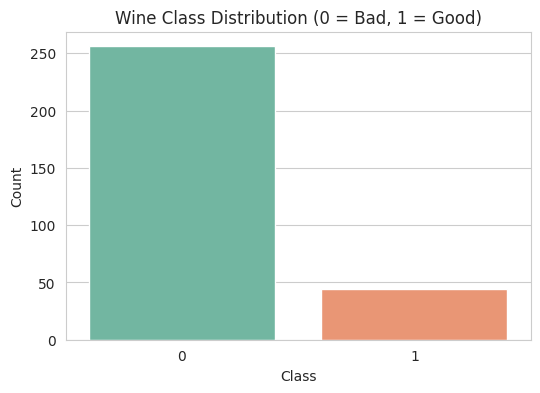

In [6]:
# Visualize the class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='good', data=df, hue='good', palette='Set2', legend=False)
plt.title('Wine Class Distribution (0 = Bad, 1 = Good)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

## Step 4: Train/Test Split (80/20)

In [7]:
# Features = all chemical columns; target = the new 'good' column
# Drop both 'quality' (raw score) and 'good' (target) from X
X = df.drop(['quality', 'good'], axis=1)
y = df['good']

print("Predictor variables (X):")
for col in X.columns:
    print(f"  - {col}")
print("\nTarget variable (y): good (1 if quality ≥ 7, else 0)")

Predictor variables (X):
  - fixed_acidity
  - volatile_acidity
  - citric_acid
  - residual_sugar
  - chlorides
  - free_sulfur_dioxide
  - total_sulfur_dioxide
  - density
  - pH
  - sulphates
  - alcohol

Target variable (y): good (1 if quality ≥ 7, else 0)


In [8]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y keeps the same class balance in both train and test sets

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("\nClass balance — Training:", y_train.value_counts().tolist())
print("Class balance — Testing :", y_test.value_counts().tolist())

Train shape: (240, 11)  | Test shape: (60, 11)

Class balance — Training: [205, 35]
Class balance — Testing : [51, 9]


## Step 5: Feature Scaling

**Why?** The chemical features have very different scales:
- `pH` ranges from ~2.7 to 4.0 (small)
- `total_sulfur_dioxide` ranges from 6 to 290 (huge)

Without scaling, gradient-based optimization is slow and unstable. **`StandardScaler`** rescales each column to **mean = 0, std = 1**.

**Critical:** fit on training data only; only `transform` test data (no fit). Otherwise, information from the test set leaks into training.

In [9]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   # learn mean+std AND transform
X_test_scaled  = sc.transform(X_test)         # only transform on test

print("After scaling, training features have mean ≈ 0 and std ≈ 1:")
print(f"  Mean: {X_train_scaled.mean(axis=0)[:3].round(3)} ...")
print(f"  Std : {X_train_scaled.std(axis=0)[:3].round(3)} ...")

After scaling, training features have mean ≈ 0 and std ≈ 1:
  Mean: [-0.  0. -0.] ...
  Std : [1. 1. 1.] ...


## Step 6: Train the Logistic Regression Model

In [10]:
# Create and train the classifier
# max_iter=1000 ensures the solver has enough iterations to converge
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [11]:
# Print the learned coefficients
coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("Learned coefficients (positive → pushes toward 'good'):")
print(coefs)
print(f"\nIntercept: {model.intercept_[0]:.4f}")

Learned coefficients (positive → pushes toward 'good'):
                 Feature  Coefficient
9              sulphates       2.2804
10               alcohol       1.6689
5    free_sulfur_dioxide       0.4053
6   total_sulfur_dioxide       0.3076
7                density       0.2623
4              chlorides       0.2605
2            citric_acid       0.2521
0          fixed_acidity       0.0513
3         residual_sugar      -0.0269
8                     pH      -0.0685
1       volatile_acidity      -0.7356

Intercept: -3.7859


## Step 7: Make Predictions

In [12]:
# predict() returns the class label (0 or 1)
y_pred = model.predict(X_test_scaled)

# predict_proba() returns probabilities for each class
y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1

# Compare predictions vs actual for the first 10 wines
preview = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability of Good': y_proba[:10].round(4)
})
preview

,Actual,Predicted,Probability of Good
0,1,1,0.6353
1,0,0,0.0518
2,0,0,0.0344
3,0,0,0.0538
4,0,0,0.0016
5,0,0,0.2722
6,0,0,0.0000
7,0,0,0.0015
8,0,0,0.0045
9,1,0,0.3662


## Step 8: Compute the Confusion Matrix

A 2×2 table that breaks predictions into four categories:

|                       | Predicted: Bad (0) | Predicted: Good (1)  |
|-----------------------|--------------------|----------------------|
| **Actual: Bad (0)**   | TN (correct ✅)    | FP (false alarm ❌)   |
| **Actual: Good (1)**  | FN (missed ❌)     | TP (correct ✅)       |

In [13]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ravel() flattens the 2x2 matrix into a tuple in order: TN, FP, FN, TP
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")

Confusion Matrix:
[[51  0]
 [ 3  6]]

True Negatives  (TN): 51
False Positives (FP): 0
False Negatives (FN): 3
True Positives  (TP): 6


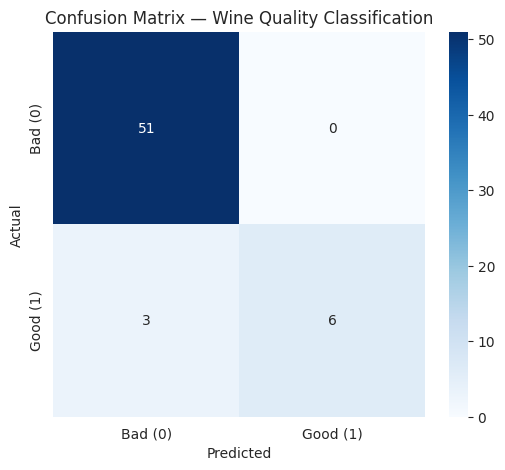

In [14]:
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad (0)', 'Good (1)'],
            yticklabels=['Bad (0)', 'Good (1)'])
plt.title('Confusion Matrix — Wine Quality Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 9: Compute Performance Metrics

All metrics are derived from the four confusion-matrix cells:

- **Accuracy** = (TP + TN) / Total
- **Error Rate** = (FP + FN) / Total = 1 − Accuracy
- **Precision** = TP / (TP + FP) — when model says "good", how often is it right
- **Recall** = TP / (TP + FN) — of all actual good wines, how many did we catch

In [15]:
total = TN + FP + FN + TP

accuracy   = (TP + TN) / total
error_rate = (FP + FN) / total
precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0

print("Performance Metrics (computed manually from TP/TN/FP/FN):")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Error Rate : {error_rate:.4f}  ({error_rate*100:.2f}%)")
print(f"  Precision  : {precision:.4f}")
print(f"  Recall     : {recall:.4f}")

Performance Metrics (computed manually from TP/TN/FP/FN):
  Accuracy   : 0.9500  (95.00%)
  Error Rate : 0.0500  (5.00%)
  Precision  : 1.0000
  Recall     : 0.6667


In [16]:
# Cross-check using sklearn's built-in functions — should match exactly
print("Cross-check using sklearn:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")

Cross-check using sklearn:
  Accuracy : 0.9500
  Precision: 1.0000
  Recall   : 0.6667


In [17]:
# Full classification report — precision, recall, F1 for both classes
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

Full Classification Report:

              precision    recall  f1-score   support

         Bad       0.94      1.00      0.97        51
        Good       1.00      0.67      0.80         9

    accuracy                           0.95        60
   macro avg       0.97      0.83      0.89        60
weighted avg       0.95      0.95      0.95        60



## Conclusion

We built a logistic regression classifier to predict wine quality (good vs bad) from 11 chemical features.

**Workflow:**
1. Created a binary target by thresholding `quality ≥ 7`
2. Split data 80/20 with stratification (preserves class balance)
3. Scaled features with `StandardScaler` (essential for logistic regression)
4. Trained `LogisticRegression`
5. Evaluated using a confusion matrix and the four key metrics

**Key insights:**
- The dataset has class imbalance (only ~14% of wines are "good"), so accuracy alone can be misleading
- **Precision** tells us how trustworthy our "good" predictions are
- **Recall** tells us how many premium wines we successfully identified
- The trade-off between them depends on the business cost — if mislabeling a bad wine as good is expensive, prioritize precision; if missing a premium wine is expensive, prioritize recall

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, reading CSVs, statistics |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization |
| **sklearn** | ML model, scaling, splitting, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — loads CSV into DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection methods
- `df['col'].value_counts()` — counts unique values

#### Target Engineering
- `(df['quality'] >= 7).astype(int)` — converts boolean Series to integer (1/0)

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` — splits data; `stratify=y` preserves class balance in both sets

#### Feature Scaling
- `StandardScaler()` — rescales features to mean=0, std=1
- `.fit_transform(X_train)` — fits scaler on training data and transforms it
- `.transform(X_test)` — applies same transformation to test (no fit!)

#### Model Training & Prediction
- `LogisticRegression(max_iter=1000, random_state=42)` — creates the classifier
- `.fit(X_train, y_train)` — trains the model
- `.predict(X_test)` — returns class labels (0/1)
- `.predict_proba(X_test)` — returns probabilities for each class
- `.coef_` — learned coefficients (one per feature)
- `.intercept_` — the b₀ term

#### Evaluation Metrics
- `confusion_matrix(y_test, y_pred)` — computes TN, FP, FN, TP
- `cm.ravel()` — flattens 2×2 matrix into a tuple (TN, FP, FN, TP)
- `accuracy_score(y_test, y_pred)` — computes accuracy
- `precision_score(y_test, y_pred)` — computes precision
- `recall_score(y_test, y_pred)` — computes recall
- `classification_report(y_test, y_pred)` — all metrics for both classes in one call

#### Visualization
- `sns.countplot(x='col', data=df)` — bar chart of category counts
- `sns.heatmap(matrix, annot=True, fmt='d')` — colored grid showing values

### Key Concepts

#### Logistic Regression
A linear classifier that predicts probabilities via the sigmoid function. The decision boundary (where σ(z) = 0.5) is a straight line/hyperplane.

#### Sigmoid Function
> σ(z) = 1 / (1 + e⁻ᶻ)

S-shaped curve that maps any real number to the range (0, 1).

#### Binary Classification
Two classes (0 vs 1). Multi-class (3+) is handled by extensions like one-vs-rest.

#### Class Imbalance
When one class is much more common than the other. Our wine dataset has only ~14% good wines, so a model that always predicted "bad" would have ~86% accuracy yet be useless.

#### Stratified Split
Ensures both train and test sets have the same class proportions. Important when classes are imbalanced.

#### Feature Scaling
Putting features on the same scale. Required for logistic regression because the optimizer is gradient-based.

#### Cost Function — Log Loss
> Cost = −(1/n) · Σ [y·log(ŷ) + (1−y)·log(1−ŷ)]

Heavily penalizes confident wrong predictions. Used because it's convex (unlike MSE for logistic regression), guaranteeing a unique global minimum.

#### Confusion Matrix
2×2 (or N×N) table showing actual vs predicted classes. The diagonal is correct predictions; off-diagonal cells are errors.

#### TP, TN, FP, FN
- **TP (True Positive)** — correctly predicted positive
- **TN (True Negative)** — correctly predicted negative
- **FP (False Positive / Type I error)** — predicted positive, actually negative
- **FN (False Negative / Type II error)** — predicted negative, actually positive

#### Accuracy, Precision, Recall
- **Accuracy** — overall correctness
- **Precision** — when model says positive, how often it's correct
- **Recall** — of all actual positives, how many model caught

#### Precision-Recall Trade-off
Lowering the threshold → higher recall, lower precision. Raising it → higher precision, lower recall. The right balance depends on the business cost of each error type.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is logistic regression?**
A linear classification algorithm that predicts the probability of belonging to a class using the sigmoid function, then assigns the class label based on a threshold (default 0.5).

**Q2. Why is it called "regression" if it does classification?**
Historical naming. The math originally came from regression analysis. In practice, it's a classification algorithm.

**Q3. Difference between linear and logistic regression?**

| | Linear Regression | Logistic Regression |
|---|------------------|---------------------|
| Output | Continuous number | Probability (0–1), then class label |
| Use case | Regression | Classification |
| Cost function | MSE | Log loss (cross-entropy) |
| Squashing function | None | Sigmoid |

**Q4. What is the sigmoid function?**
σ(z) = 1/(1 + e⁻ᶻ). It squashes any real number into (0, 1) so the output can be interpreted as a probability.

**Q5. What is the decision boundary?**
The line/plane where the predicted probability = 0.5, defined by `b₀ + b₁·x₁ + ... = 0`.

**Q6. Is logistic regression linear or non-linear?**
**Linear** — the decision boundary is a straight line (in 2D). It cannot capture curved relationships without feature engineering.

### Math / Algorithm

**Q7. What is the cost function for logistic regression?**
**Log loss** (binary cross-entropy): Cost = −(1/n)·Σ[y·log(ŷ) + (1−y)·log(1−ŷ)]. Heavily penalizes confident wrong predictions.

**Q8. Why not use MSE?**
Applying MSE to logistic regression creates a non-convex cost surface with multiple local minima — gradient descent gets stuck. Log loss is convex, guaranteeing a unique global minimum.

**Q9. How are parameters learned?**
Through **maximum likelihood estimation (MLE)**, optimized via gradient-based methods (gradient descent, L-BFGS).

**Q10. Why is feature scaling needed?**
Logistic regression uses gradient-based optimization. Different feature scales make the cost surface elongated, slowing convergence.

### Confusion Matrix & Metrics

**Q11. What is a confusion matrix?**
A table showing actual vs predicted classes. For binary classification it's 2×2: TN, FP, FN, TP.

**Q12. Define TP, TN, FP, FN.**
- **TP**: predicted positive, actually positive
- **TN**: predicted negative, actually negative
- **FP**: predicted positive, actually negative (Type I error)
- **FN**: predicted negative, actually positive (Type II error)

**Q13. Accuracy formula?**
(TP + TN) / Total.

**Q14. When is accuracy misleading?**
When classes are imbalanced. A model that always predicts the majority class can have high accuracy and still be useless.

**Q15. Define Precision.**
TP / (TP + FP). When model says positive, how often is it correct.

**Q16. Define Recall.**
TP / (TP + FN). Of all actual positives, how many did the model catch.

**Q17. When does precision matter more than recall?**
When false positives are costly — spam filters, premium-wine labeling, biopsy follow-ups.

**Q18. When does recall matter more than precision?**
When false negatives are costly — cancer screening, fraud detection, safety alerts.

**Q19. What is the F1-score?**
Harmonic mean of precision and recall: 2·P·R/(P+R). Useful when you need a single combined metric.

**Q20. What is the precision-recall trade-off?**
Lowering the threshold raises recall but drops precision. Raising it does the opposite.

### Practical / Code

**Q21. What does `predict()` do vs `predict_proba()`?**
- `predict()` returns the class label (0 or 1)
- `predict_proba()` returns the probability for each class

**Q22. What does `random_state` do?**
Seeds the random number generator so results are reproducible.

**Q23. Why fit_transform on train but only transform on test?**
The scaler must learn its parameters (mean, std) from training data only. Letting it see test data is **data leakage** and inflates test scores artificially.

**Q24. What does `stratify=y` do in train_test_split?**
Ensures both train and test sets keep the same class proportions as the full dataset. Important for imbalanced classes.

**Q25. How would you handle class imbalance?**
- Use `class_weight='balanced'` in `LogisticRegression`
- Oversample the minority class (SMOTE)
- Undersample the majority class
- Adjust the decision threshold

### Comparison

**Q26. Why use logistic regression over decision trees?**
- Faster, more interpretable
- Outputs calibrated probabilities (decision trees don't natively)
- Better when classes are roughly linearly separable

**Q27. When does logistic regression fail?**
- When the decision boundary is highly non-linear
- When features have strong interactions the model can't capture

**Q28. What's the next algorithm to try if logistic regression underperforms?**
Random Forest or XGBoost — both handle non-linearity automatically.